## 1. Librerías y Configuración


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Any
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 100)


## 2. Carga del Dataset


In [ ]:
df = pd.read_excel('../OPERA POSTQX.xlsx')

print("=" * 80)
print("INFORMACIÓN BÁSICA DEL DATASET")
print("=" * 80)
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nTipos de datos:")
print(df.dtypes.value_counts())


INFORMACIÓN BÁSICA DEL DATASET
Dimensiones: 29,865 filas × 76 columnas
Memoria: 63.64 MB

Tipos de datos:
object            44
float64           22
int64              5
datetime64[ns]     5
Name: count, dtype: int64


In [ ]:
# Listado completo de columnas con tipo
print("LISTADO DE COLUMNAS")
print("=" * 80)
for i, (col, dtype) in enumerate(df.dtypes.items()):
    print(f"{i+1:02d}. {col} [{dtype}]")


LISTADO DE COLUMNAS
01. Documento PMD (valoración preanestésica) [int64]
02. Número de episodio (valoración preanestésica) [int64]
03. Prestacion actual consulta anestesia [int64]
04. Preadmision anestesia [int64]
05. Orden [int64]
06. Preadmision Proced [float64]
07. Nombres y Apellidos [object]
08. Tipo de identificación [object]
09. Número de identificación [object]
10. Cirugia [object]
11. Otros procedimientos [object]
12. N° Documento [float64]
13. Fecha proced [datetime64[ns]]
14. Prestacion [object]
15. Desc Prestacion [object]
16. estado [object]
17. Paciente [float64]
18. Número de episodio  [float64]
19. Infarto de miocardio en hospital [object]
20. Accidente cerebrovascular isquémico [float64]
21. Accidente cerebrovascular hemorrágico [object]
22. Ataque isquémico transitorio (TIA) [object]
23. Aspiración pulmonar [object]
24. Complicaciones pulmonares posoperatorias  [object]
25. Cancelación de procedimiento - episodio consulta preanes [object]
26. Cancelación de procedimie

## 3. Funciones de Análisis


In [ ]:
def analyze_column(df: pd.DataFrame, column: str) -> Dict[str, Any]:
    """Analiza una columna y retorna un diccionario con estadísticas."""
    if column not in df.columns:
        return {"error": f"Columna '{column}' no encontrada"}
    
    series = df[column]
    n_total = len(series)
    n_null = series.isna().sum()
    n_valid = n_total - n_null
    
    stats = {
        "columna": column,
        "tipo": str(series.dtype),
        "total": n_total,
        "nulos": n_null,
        "nulos_pct": round(n_null / n_total * 100, 2),
        "validos": n_valid,
        "validos_pct": round(n_valid / n_total * 100, 2),
        "unicos": series.nunique(dropna=True),
    }
    
    # Estadísticas adicionales según el tipo
    if np.issubdtype(series.dtype, np.number):
        non_null = series.dropna()
        if len(non_null) > 0:
            stats.update({
                "min": float(non_null.min()),
                "max": float(non_null.max()),
                "media": round(float(non_null.mean()), 2),
                "mediana": float(non_null.median()),
                "std": round(float(non_null.std()), 2),
            })
    
    # Top valores
    stats["top_valores"] = series.value_counts(dropna=False).head(10).to_dict()
    
    return stats


def print_column_analysis(stats: Dict[str, Any]) -> None:
    """Imprime el análisis de forma legible."""
    print(f"\n{'='*70}")
    print(f"COLUMNA: {stats.get('columna', 'N/A')}")
    print(f"{'='*70}")
    print(f"Tipo: {stats.get('tipo', 'N/A')}")
    print(f"Total: {stats.get('total', 0):,} | Válidos: {stats.get('validos', 0):,} ({stats.get('validos_pct', 0)}%) | Nulos: {stats.get('nulos', 0):,} ({stats.get('nulos_pct', 0)}%)")
    print(f"Valores únicos: {stats.get('unicos', 0)}")
    
    if 'media' in stats:
        print(f"\nEstadísticas numéricas:")
        print(f"  Min: {stats.get('min')} | Max: {stats.get('max')}")
        print(f"  Media: {stats.get('media')} | Mediana: {stats.get('mediana')} | Std: {stats.get('std')}")
    
    print(f"\nTop 10 valores:")
    for i, (val, count) in enumerate(stats.get('top_valores', {}).items()):
        pct = count / stats.get('total', 1) * 100
        print(f"  {i+1:2d}. {repr(val)}: {count:,} ({pct:.2f}%)")


## 4. Análisis por Categoría de Variables

### 4.1 Variables de Identificación


In [ ]:
# Variables de identificación y administrativas
ID_COLS = [
    'Documento PMD (valoración preanestésica)',
    'Número de episodio (valoración preanestésica)',
    'Prestacion actual consulta anestesia',
    'Preadmision anestesia',
    'Orden',
    'Preadmision Proced',
    'Nombres y Apellidos',
    'Tipo de identificación',
    'Número de identificación',
    'N° Documento',
    'Paciente',
    'Número de episodio '
]

print("VARIABLES DE IDENTIFICACIÓN")
print("=" * 80)
for col in ID_COLS:
    if col in df.columns:
        stats = analyze_column(df, col)
        print_column_analysis(stats)


VARIABLES DE IDENTIFICACIÓN

COLUMNA: Documento PMD (valoración preanestésica)
Tipo: int64
Total: 29,865 | Válidos: 29,865 (100.0%) | Nulos: 0 (0.0%)
Valores únicos: 29865

Estadísticas numéricas:
  Min: 1000025801070.0 | Max: 1000060990969.0
  Media: 1000042485324.28 | Mediana: 1000042348368.0 | Std: 10246376.43

Top 10 valores:
   1. 1000026183616: 1 (0.00%)
   2. 1000026803024: 1 (0.00%)
   3. 1000029560359: 1 (0.00%)
   4. 1000026726129: 1 (0.00%)
   5. 1000027686761: 1 (0.00%)
   6. 1000026032874: 1 (0.00%)
   7. 1000026134085: 1 (0.00%)
   8. 1000026296908: 1 (0.00%)
   9. 1000026548489: 1 (0.00%)
  10. 1000025850283: 1 (0.00%)

COLUMNA: Número de episodio (valoración preanestésica)
Tipo: int64
Total: 29,865 | Válidos: 29,865 (100.0%) | Nulos: 0 (0.0%)
Valores únicos: 29808

Estadísticas numéricas:
  Min: 5574494.0 | Max: 13385864.0
  Media: 9488559.47 | Mediana: 9444697.0 | Std: 2160107.47

Top 10 valores:
   1. 9509360: 3 (0.01%)
   2. 6506577: 2 (0.01%)
   3. 8032516: 2 (0.01%

### 4.2 Variables del Procedimiento


In [6]:
# Variables relacionadas con el procedimiento
PROC_COLS = [
    'Cirugia',
    'Otros procedimientos',
    'Fecha proced',
    'Prestacion',
    'Desc Prestacion',
    'estado'
]

print("VARIABLES DEL PROCEDIMIENTO")
print("=" * 80)
for col in PROC_COLS:
    if col in df.columns:
        stats = analyze_column(df, col)
        print_column_analysis(stats)


VARIABLES DEL PROCEDIMIENTO

COLUMNA: Cirugia
Tipo: object
Total: 29,865 | Válidos: 23,525 (78.77%) | Nulos: 6,340 (21.23%)
Valores únicos: 1

Top 10 valores:
   1. 'X': 23,525 (78.77%)
   2. nan: 6,340 (21.23%)

COLUMNA: Otros procedimientos
Tipo: object
Total: 29,865 | Válidos: 4,324 (14.48%) | Nulos: 25,541 (85.52%)
Valores únicos: 1

Top 10 valores:
   1. nan: 25,541 (85.52%)
   2. 'X': 4,324 (14.48%)

COLUMNA: Fecha proced
Tipo: datetime64[ns]
Total: 29,865 | Válidos: 27,849 (93.25%) | Nulos: 2,016 (6.75%)
Valores únicos: 2214

Top 10 valores:
   1. NaT: 2,016 (6.75%)
   2. Timestamp('2022-11-30 00:00:00'): 33 (0.11%)
   3. Timestamp('2021-11-17 00:00:00'): 30 (0.10%)
   4. Timestamp('2021-07-26 00:00:00'): 29 (0.10%)
   5. Timestamp('2023-11-22 00:00:00'): 29 (0.10%)
   6. Timestamp('2019-12-09 00:00:00'): 29 (0.10%)
   7. Timestamp('2025-04-30 00:00:00'): 28 (0.09%)
   8. Timestamp('2024-08-23 00:00:00'): 27 (0.09%)
   9. Timestamp('2022-05-06 00:00:00'): 27 (0.09%)
  10. Timest

### 4.3 Variables de Complicaciones Médicas (Candidatas para Target)

Estas variables contienen códigos CIE-10 que indican complicaciones durante o después de la cirugía.


In [7]:
# Variables de complicaciones médicas (códigos CIE-10)
COMPLICACIONES_MEDICAS_COLS = [
    'Infarto de miocardio en hospital',
    'Accidente cerebrovascular isquémico',
    'Accidente cerebrovascular hemorrágico',
    'Ataque isquémico transitorio (TIA)',
    'Aspiración pulmonar',
    'Complicaciones pulmonares posoperatorias ',
    'Complicaciones '
]

print("VARIABLES DE COMPLICACIONES MÉDICAS (CIE-10)")
print("=" * 80)
print("\n⚠️ NOTA: Estas variables contienen códigos CIE-10. Un valor NO nulo indica complicación.\n")
for col in COMPLICACIONES_MEDICAS_COLS:
    if col in df.columns:
        stats = analyze_column(df, col)
        print_column_analysis(stats)


VARIABLES DE COMPLICACIONES MÉDICAS (CIE-10)

⚠️ NOTA: Estas variables contienen códigos CIE-10. Un valor NO nulo indica complicación.


COLUMNA: Infarto de miocardio en hospital
Tipo: object
Total: 29,865 | Válidos: 12 (0.04%) | Nulos: 29,853 (99.96%)
Valores únicos: 2

Top 10 valores:
   1. nan: 29,853 (99.96%)
   2. 'I219': 11 (0.04%)
   3. 'I214': 1 (0.00%)

COLUMNA: Accidente cerebrovascular isquémico
Tipo: float64
Total: 29,865 | Válidos: 0 (0.0%) | Nulos: 29,865 (100.0%)
Valores únicos: 0

Top 10 valores:
   1. nan: 29,865 (100.00%)

COLUMNA: Accidente cerebrovascular hemorrágico
Tipo: object
Total: 29,865 | Válidos: 6 (0.02%) | Nulos: 29,859 (99.98%)
Valores únicos: 2

Top 10 valores:
   1. nan: 29,859 (99.98%)
   2. 'I618': 5 (0.02%)
   3. 'I619': 1 (0.00%)

COLUMNA: Ataque isquémico transitorio (TIA)
Tipo: object
Total: 29,865 | Válidos: 9 (0.03%) | Nulos: 29,856 (99.97%)
Valores únicos: 4

Top 10 valores:
   1. nan: 29,856 (99.97%)
   2. 'G459': 4 (0.01%)
   3. 'G458': 2 (0.

### 4.4 Variables de Cancelación de Procedimientos


In [ ]:
# Variables de cancelación
CANCELACION_COLS = [
    'Cancelación de procedimiento - episodio consulta preanes',
    'Cancelación de procedimiento - episodio procedimiento'
]

print("VARIABLES DE CANCELACIÓN")
print("=" * 80)
print("\n⚠️ NOTA: 'C-CA por Pcte' = cancelación por paciente (NO es complicación médica)")
print("         'C-CA por Médico' = cancelación por médico (SÍ indica problema)\n")
for col in CANCELACION_COLS:
    if col in df.columns:
        stats = analyze_column(df, col)
        print_column_analysis(stats)


VARIABLES DE CANCELACIÓN

⚠️ NOTA: 'C-CA por Pcte' = cancelación por paciente (NO es complicación médica)
         'C-CA por Médico' = cancelación por médico (SÍ indica problema)


COLUMNA: Cancelación de procedimiento - episodio consulta preanes
Tipo: object
Total: 29,865 | Válidos: 86 (0.29%) | Nulos: 29,779 (99.71%)
Valores únicos: 3

Top 10 valores:
   1. nan: 29,779 (99.71%)
   2. 'C-CA por Pcte': 70 (0.23%)
   3. 'C-CA por Médico': 12 (0.04%)
   4. 'C-E. Admin': 4 (0.01%)

COLUMNA: Cancelación de procedimiento - episodio procedimiento
Tipo: object
Total: 29,865 | Válidos: 763 (2.55%) | Nulos: 29,102 (97.45%)
Valores únicos: 8

Top 10 valores:
   1. nan: 29,102 (97.45%)
   2. 'C-CA por Pcte': 485 (1.62%)
   3. 'C-CA por Médico': 197 (0.66%)
   4. 'C-E. Admin': 59 (0.20%)
   5. 'C-Mot IntFVL': 11 (0.04%)
   6. 'C-Canc.Aut': 4 (0.01%)
   7. 'C-Aut Otra Ent': 3 (0.01%)
   8. 'C-Equi Dañado': 3 (0.01%)
   9. 'C-Cancelado WP': 1 (0.00%)


### 4.5 Variables de Estancia Hospitalaria y Destino


In [ ]:
# Variables de estancia y destinoESTANCIA_COLS = [    'Estancia hospitalaria ',    'Hospitalización no anticipada',    'Admisión a cuidado intensivo no planeada',    'Estancia en UCI ',    'Destino final ']print("VARIABLES DE ESTANCIA Y DESTINO")print("=" * 80)print("\nNOTAS:")print("  - 'Hospitalización no anticipada': 'x' indica hospitalización no planeada")print("  - 'Admisión a UCI no planeada': fecha presente indica admisión")print("  - 'Destino final': 'UCI' vs 'UCPA' (recuperación normal)\n")for col in ESTANCIA_COLS:    if col in df.columns:        stats = analyze_column(df, col)        print_column_analysis(stats)

### 4.6 Variables de Seguimiento Post-Cirugía


In [10]:
# Variables de seguimiento
SEGUIMIENTO_COLS = [
    'Consulta a urgencias en los siguientes 30 días',
    'Necesidad de interconsultas a otras especialidades médicas',
    'Reserva de hemoderivados',
    'Reserva de sangre '
]

print("VARIABLES DE SEGUIMIENTO POST-CIRUGÍA")
print("=" * 80)
print("\nNOTAS:")
print("  - 'Consulta a urgencias': fecha presente indica visita a urgencias")
print("  - 'Necesidad de interconsultas': 'x' indica que requirió interconsulta")
print("  - 'Reserva de hemoderivados': código 912002 = transfusión de sangre necesaria")
print("  - 'Reserva de sangre': 0=vacío, 1=Sí, 2=No\n")
for col in SEGUIMIENTO_COLS:
    if col in df.columns:
        stats = analyze_column(df, col)
        print_column_analysis(stats)


VARIABLES DE SEGUIMIENTO POST-CIRUGÍA

NOTAS:
  - 'Consulta a urgencias': fecha presente indica visita a urgencias
  - 'Necesidad de interconsultas': 'x' indica que requirió interconsulta
  - 'Reserva de hemoderivados': código 912002 = transfusión de sangre necesaria
  - 'Reserva de sangre': 0=vacío, 1=Sí, 2=No


COLUMNA: Consulta a urgencias en los siguientes 30 días
Tipo: datetime64[ns]
Total: 29,865 | Válidos: 1,197 (4.01%) | Nulos: 28,668 (95.99%)
Valores únicos: 926

Top 10 valores:
   1. NaT: 28,668 (95.99%)
   2. Timestamp('2024-06-20 00:00:00'): 5 (0.02%)
   3. Timestamp('2022-06-06 00:00:00'): 5 (0.02%)
   4. Timestamp('2021-09-02 00:00:00'): 4 (0.01%)
   5. Timestamp('2024-09-20 00:00:00'): 4 (0.01%)
   6. Timestamp('2022-04-30 00:00:00'): 4 (0.01%)
   7. Timestamp('2022-10-10 00:00:00'): 4 (0.01%)
   8. Timestamp('2025-04-10 00:00:00'): 3 (0.01%)
   9. Timestamp('2024-03-12 00:00:00'): 3 (0.01%)
  10. Timestamp('2021-03-21 00:00:00'): 3 (0.01%)

COLUMNA: Necesidad de interco

### 4.7 Variables Fisiológicas Prequirúrgicas


In [11]:
# Variables fisiológicas prequirúrgicas
FISIOLOGICAS_COLS = [
    'Presión arterial sistólica prequirúrgica ',
    'Presión arterial diastólica prequirúrgica',
    'Presión arterial media prequirúrgica',
    'Frecuencia cardiaca prequirúrgica',
    'Saturación de oxígeno prequirúrgica',
    'Temperatura prequirúrgica',
    'Glucometría prequirúrgica ',
    'Valor glucometria '
]

print("VARIABLES FISIOLÓGICAS PREQUIRÚRGICAS")
print("=" * 80)
for col in FISIOLOGICAS_COLS:
    if col in df.columns:
        stats = analyze_column(df, col)
        print_column_analysis(stats)


VARIABLES FISIOLÓGICAS PREQUIRÚRGICAS

COLUMNA: Presión arterial sistólica prequirúrgica 
Tipo: float64
Total: 29,865 | Válidos: 23,546 (78.84%) | Nulos: 6,319 (21.16%)
Valores únicos: 146

Estadísticas numéricas:
  Min: 0.0 | Max: 921.0
  Media: 114.05 | Mediana: 118.0 | Std: 33.11

Top 10 valores:
   1. nan: 6,319 (21.16%)
   2. 0.0: 1,315 (4.40%)
   3. 120.0: 609 (2.04%)
   4. 116.0: 596 (2.00%)
   5. 114.0: 577 (1.93%)
   6. 123.0: 565 (1.89%)
   7. 115.0: 549 (1.84%)
   8. 117.0: 545 (1.82%)
   9. 121.0: 537 (1.80%)
  10. 119.0: 533 (1.78%)

COLUMNA: Presión arterial diastólica prequirúrgica
Tipo: float64
Total: 29,865 | Válidos: 23,546 (78.84%) | Nulos: 6,319 (21.16%)
Valores únicos: 122

Estadísticas numéricas:
  Min: 0.0 | Max: 995.0
  Media: 70.27 | Mediana: 73.0 | Std: 29.35

Top 10 valores:
   1. nan: 6,319 (21.16%)
   2. 0.0: 1,317 (4.41%)
   3. 74.0: 835 (2.80%)
   4. 77.0: 818 (2.74%)
   5. 70.0: 792 (2.65%)
   6. 71.0: 789 (2.64%)
   7. 72.0: 787 (2.64%)
   8. 76.0: 758 

### 4.8 Variables Intraoperatorias


In [12]:
# Variables intraoperatorias
INTRAOP_COLS = [
    'Inicio cirujano ',
    'Fin cirujano ',
    'Inicio anestesia ',
    'Fin anestesia ',
    'Clasificación ASA intraoperatorio',
    'Clasificación NYHA intraoperatorio ',
    'Clase de inducción ',
    'Intubación  ',
    'Laringoscopia ',
    'Tipo de intubación',
    'Hoja de laringoscopio ',
    'Elemento de vía aérea utilizado ',
    'Técnica anestésica ',
    'Monitoreo ',
    'Estado intubación ',
    'Fallecimiento durante cirugía '
]

print("VARIABLES INTRAOPERATORIAS")
print("=" * 80)
for col in INTRAOP_COLS:
    if col in df.columns:
        stats = analyze_column(df, col)
        print_column_analysis(stats)


VARIABLES INTRAOPERATORIAS

COLUMNA: Inicio cirujano 
Tipo: datetime64[ns]
Total: 29,865 | Válidos: 24,016 (80.42%) | Nulos: 5,849 (19.58%)
Valores únicos: 23190

Top 10 valores:
   1. NaT: 5,849 (19.58%)
   2. Timestamp('2022-07-15 08:00:00'): 4 (0.01%)
   3. Timestamp('2022-12-19 07:20:00'): 4 (0.01%)
   4. Timestamp('2022-07-18 09:00:00'): 4 (0.01%)
   5. Timestamp('2022-07-01 08:05:00'): 3 (0.01%)
   6. Timestamp('2022-01-12 15:05:00'): 3 (0.01%)
   7. Timestamp('2021-03-02 08:20:00'): 3 (0.01%)
   8. Timestamp('2019-06-18 08:15:00'): 3 (0.01%)
   9. Timestamp('2021-03-18 07:35:00'): 3 (0.01%)
  10. Timestamp('2021-03-02 07:55:00'): 3 (0.01%)

COLUMNA: Fin cirujano 
Tipo: datetime64[ns]
Total: 29,865 | Válidos: 23,958 (80.22%) | Nulos: 5,907 (19.78%)
Valores únicos: 23385

Top 10 valores:
   1. NaT: 5,907 (19.78%)
   2. Timestamp('2022-04-19 18:25:00'): 4 (0.01%)
   3. Timestamp('2020-03-02 11:00:00'): 3 (0.01%)
   4. Timestamp('2022-08-03 11:10:00'): 3 (0.01%)
   5. Timestamp('202

### 4.9 Variables de Ventilación y Líquidos


In [ ]:
# Variables de ventilación y líquidos
VENT_LIQ_COLS = [
    'Ventilación espontánea ',
    'Ventilación asistida ',
    'Control manual ',
    'Control volumen',
    'Presión soporte ',
    'Control ventilatorio ',
    'Control presión ',
    'SIMV/PS',
    'VT',
    'PEEP',
    'Frecuencia respiratoria ',
    'Líquidos administrados ',
    'VOLUMEN LIQUIDOS ADMINISTRADOS',
    'Liquidos eliminados',
    'Volumen de liquidos eliminados ',
    'Balance de líquidos '
]

print("VARIABLES DE VENTILACIÓN Y LÍQUIDOS")
print("=" * 80)
for col in VENT_LIQ_COLS:
    if col in df.columns:
        stats = analyze_column(df, col)
        print_column_analysis(stats)


VARIABLES DE VENTILACIÓN Y LÍQUIDOS

COLUMNA: Ventilación espontánea 
Tipo: object
Total: 29,865 | Válidos: 7,777 (26.04%) | Nulos: 22,088 (73.96%)
Valores únicos: 1

Top 10 valores:
   1. nan: 22,088 (73.96%)
   2. 'X': 7,777 (26.04%)

COLUMNA: Ventilación asistida 
Tipo: object
Total: 29,865 | Válidos: 548 (1.83%) | Nulos: 29,317 (98.17%)
Valores únicos: 1

Top 10 valores:
   1. nan: 29,317 (98.17%)
   2. 'X': 548 (1.83%)

COLUMNA: Control manual 
Tipo: object
Total: 29,865 | Válidos: 545 (1.82%) | Nulos: 29,320 (98.18%)
Valores únicos: 1

Top 10 valores:
   1. nan: 29,320 (98.18%)
   2. 'X': 545 (1.82%)

COLUMNA: Control volumen
Tipo: object
Total: 29,865 | Válidos: 1,786 (5.98%) | Nulos: 28,079 (94.02%)
Valores únicos: 1

Top 10 valores:
   1. nan: 28,079 (94.02%)
   2. 'X': 1,786 (5.98%)

COLUMNA: Presión soporte 
Tipo: object
Total: 29,865 | Válidos: 505 (1.69%) | Nulos: 29,360 (98.31%)
Valores únicos: 1

Top 10 valores:
   1. nan: 29,360 (98.31%)
   2. 'X': 505 (1.69%)

COLUMNA:

## 5. Resumen: Variables Candidatas para la Variable Objetivo

Basado en el análisis exploratorio, las siguientes variables son candidatas para construir la variable objetivo:


In [14]:
# Resumen de variables candidatas para el target
print("=" * 80)
print("RESUMEN DE VARIABLES CANDIDATAS PARA TARGET")
print("=" * 80)

# Calcular conteo de casos positivos por variable
resumen = []

# Complicaciones CIE-10
for col in COMPLICACIONES_MEDICAS_COLS:
    if col in df.columns:
        n_casos = df[col].notna().sum()
        resumen.append({
            'Variable': col.strip(),
            'Categoría': 'CIE-10',
            'Casos positivos': n_casos,
            'Porcentaje': round(n_casos / len(df) * 100, 2),
            'Criterio': 'Valor no nulo'
        })

# Cancelaciones (excluyendo por paciente)
for col in CANCELACION_COLS:
    if col in df.columns:
        n_casos = df[col].apply(lambda x: pd.notna(x) and x != 'C-CA por Pcte').sum()
        resumen.append({
            'Variable': col.strip()[:50],
            'Categoría': 'Cancelación',
            'Casos positivos': n_casos,
            'Porcentaje': round(n_casos / len(df) * 100, 2),
            'Criterio': 'Cancelación médica'
        })

# Estancia
if 'Hospitalización no anticipada' in df.columns:
    n_casos = (df['Hospitalización no anticipada'].str.lower().str.strip() == 'x').sum()
    resumen.append({
        'Variable': 'Hospitalización no anticipada',
        'Categoría': 'Estancia',
        'Casos positivos': n_casos,
        'Porcentaje': round(n_casos / len(df) * 100, 2),
        'Criterio': 'Marcado con x'
    })

if 'Admisión a cuidado intensivo no planeada' in df.columns:
    n_casos = df['Admisión a cuidado intensivo no planeada'].notna().sum()
    resumen.append({
        'Variable': 'Admisión a UCI no planeada',
        'Categoría': 'Estancia',
        'Casos positivos': n_casos,
        'Porcentaje': round(n_casos / len(df) * 100, 2),
        'Criterio': 'Tiene fecha'
    })

if 'Destino final ' in df.columns:
    n_casos = (df['Destino final '].str.upper().str.strip() == 'UCI').sum()
    resumen.append({
        'Variable': 'Destino final = UCI',
        'Categoría': 'Estancia',
        'Casos positivos': n_casos,
        'Porcentaje': round(n_casos / len(df) * 100, 2),
        'Criterio': 'Valor = UCI'
    })

# Seguimiento
if 'Consulta a urgencias en los siguientes 30 días' in df.columns:
    n_casos = df['Consulta a urgencias en los siguientes 30 días'].notna().sum()
    resumen.append({
        'Variable': 'Consulta urgencias 30 días',
        'Categoría': 'Seguimiento',
        'Casos positivos': n_casos,
        'Porcentaje': round(n_casos / len(df) * 100, 2),
        'Criterio': 'Tiene fecha'
    })

if 'Necesidad de interconsultas a otras especialidades médicas' in df.columns:
    n_casos = (df['Necesidad de interconsultas a otras especialidades médicas'].str.lower().str.strip() == 'x').sum()
    resumen.append({
        'Variable': 'Necesidad interconsultas',
        'Categoría': 'Seguimiento',
        'Casos positivos': n_casos,
        'Porcentaje': round(n_casos / len(df) * 100, 2),
        'Criterio': 'Marcado con x'
    })

# Mostrar resumen como tabla
df_resumen = pd.DataFrame(resumen)
df_resumen = df_resumen.sort_values('Casos positivos', ascending=False)
print(df_resumen.to_string(index=False))


RESUMEN DE VARIABLES CANDIDATAS PARA TARGET
                                          Variable   Categoría  Casos positivos  Porcentaje           Criterio
                     Hospitalización no anticipada    Estancia             5273       17.66      Marcado con x
                          Necesidad interconsultas Seguimiento             1230        4.12      Marcado con x
                        Consulta urgencias 30 días Seguimiento             1197        4.01        Tiene fecha
                        Admisión a UCI no planeada    Estancia              670        2.24        Tiene fecha
                               Destino final = UCI    Estancia              372        1.25        Valor = UCI
Cancelación de procedimiento - episodio procedimie Cancelación              278        0.93 Cancelación médica
          Complicaciones pulmonares posoperatorias      CIE-10              174        0.58      Valor no nulo
Cancelación de procedimiento - episodio consulta p Cancelación      

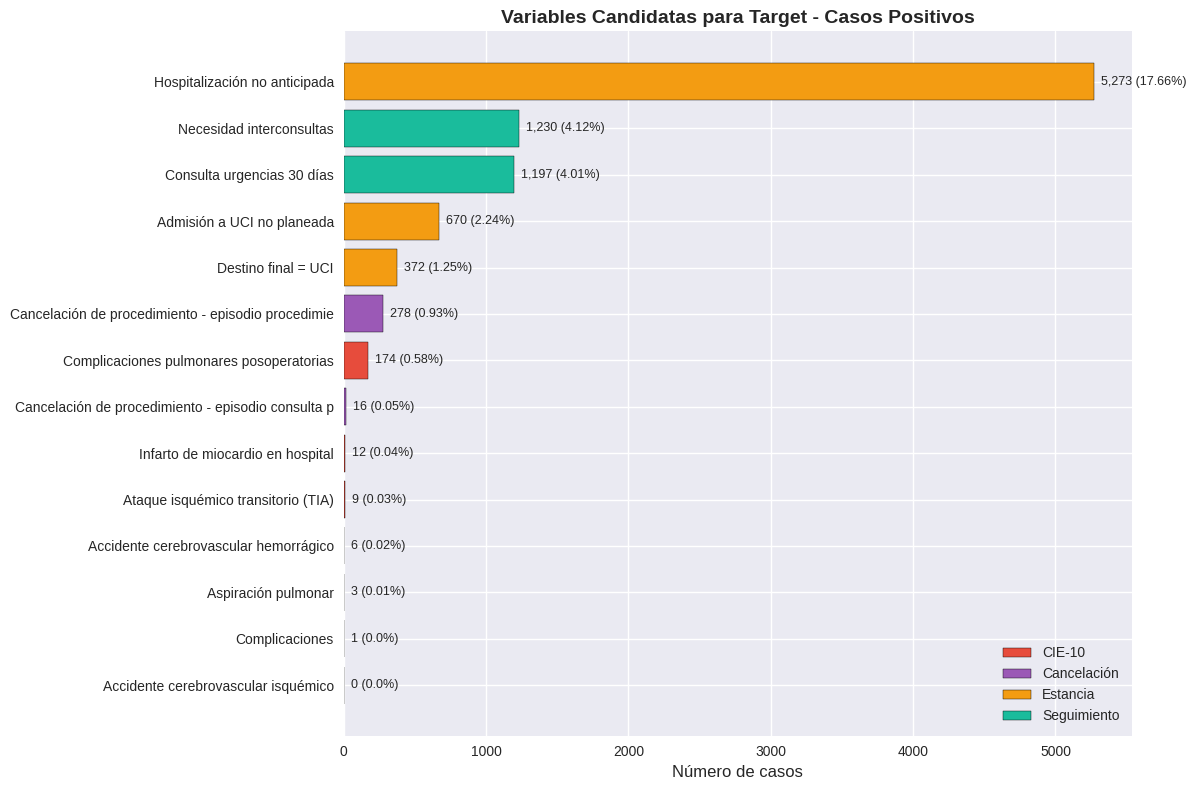

In [15]:
# Visualización del resumen
fig, ax = plt.subplots(figsize=(12, 8))

# Colores por categoría
color_map = {
    'CIE-10': '#e74c3c',
    'Cancelación': '#9b59b6',
    'Estancia': '#f39c12',
    'Seguimiento': '#1abc9c'
}

colors = [color_map.get(cat, '#95a5a6') for cat in df_resumen['Categoría']]

bars = ax.barh(df_resumen['Variable'], df_resumen['Casos positivos'], color=colors, edgecolor='black')
ax.set_xlabel('Número de casos', fontsize=12)
ax.set_title('Variables Candidatas para Target - Casos Positivos', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Agregar etiquetas
for bar, pct in zip(bars, df_resumen['Porcentaje']):
    width = bar.get_width()
    ax.annotate(f'{int(width):,} ({pct}%)',
                xy=(width, bar.get_y() + bar.get_height()/2),
                xytext=(5, 0), textcoords='offset points',
                ha='left', va='center', fontsize=9)

# Leyenda
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, edgecolor='black', label=cat) 
                   for cat, color in color_map.items()]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()
